# Imports

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import ctypes

import json
from pathlib import Path

from numpy.matlib import rand

lib = ctypes.cdll.LoadLibrary('../lib_classification/target/release/lib_classification.dll')

from rust_bridge import TaskMode, RBFModelRust, OVRRBF

lib.lloyd.argtypes = [ctypes.c_uint32, ctypes.POINTER(ctypes.c_float), ctypes.POINTER(ctypes.c_float), ctypes.POINTER(ctypes.c_float), ctypes.c_uint32, ctypes.c_float, ctypes.c_float, ctypes.POINTER(ctypes.c_float) ]
lib.lloyd.restype = None




# Cas de tests, rendu 2

## Classification

### Linear Simple :
        Linear Model : OK
        MLP (2, 1)   : OK

In [3]:
X = np.array([
      [1, 1],
      [2, 3],
      [3, 3]
], dtype=np.float32)
Y = np.array([
      1,
      -1,
      -1
], dtype=np.float32)

### CODE ADDED :

### PLOT CREATION

In [4]:
# RBF MODEL
rbf = RBFModelRust(input_dim=2, nb_cluster=2, seed=42)

y_reshape = Y.reshape(-1, 1).astype(np.float32)

rbf.entrainement(X, y_reshape, 0.0001, 300, 1)


##### MODEL PREDICTION


In [5]:
points_to_predict_ = []
predicted_colors = []
for row in range(400):
  for col in range(400):
    point_to_predict_ = np.array(([row/100.0, col/100.0]), dtype = np.float32)
    points_to_predict_.append(point_to_predict_)
    pred = rbf.prediction(point_to_predict_.reshape(1, -1))


    predicted_colors.append(
            'lightblue' if pred[0] >= 0 else 'pink')
points_to_predict_ = np.array(points_to_predict_)

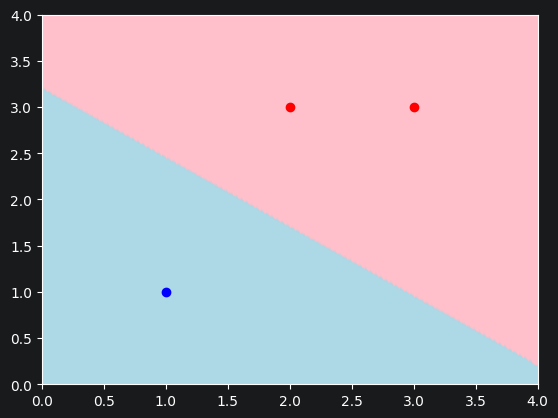

<Figure size 640x480 with 0 Axes>

In [6]:
plt.scatter(points_to_predict_[:, 0], points_to_predict_[:, 1], c=predicted_colors)

plt.scatter(X[0, 0], X[0, 1], color='blue')
plt.scatter(X[1:3,0], X[1:3,1], color='red')
#plt.scatter(clusters[:,0],clusters[:,1],marker = 'x', s = 100)

plt.xlim(0, 4)
plt.ylim(0, 4)
plt.show()
plt.clf()
rbf.close()

### Linear Multiple :
        Linear Model : OK
        MLP (2, 1)   : OK

In [7]:
X = np.concatenate([np.random.random((50,2)) * 0.9 + np.array([1, 1]), np.random.random((50,2)) * 0.9 + np.array([2, 2])], dtype=np.float32)

Y = np.concatenate([np.ones(50, dtype=np.float32), np.ones(50, dtype=np.float32) * -1.0])

### CODE ADDED :

In [8]:
# RBF MODEL

'''
data_ptr = X.ctypes.data_as(ctypes.POINTER(ctypes.c_float))
label_ptr = Y.ctypes.data_as(ctypes.POINTER(ctypes.c_float))

env_x = np.array([0.0, 4.0], dtype=np.float32)
env_y = np.array([0.0, 4.0], dtype=np.float32)
env_x_ptr = env_x.ctypes.data_as(ctypes.POINTER(ctypes.c_float))
env_y_ptr = env_y.ctypes.data_as(ctypes.POINTER(ctypes.c_float))

num_k = 2

output = np.zeros(num_k * 2, dtype=np.float32)
output_ptr = output.ctypes.data_as(ctypes.POINTER(ctypes.c_float))



lib.lloyd(num_k, env_x_ptr, env_y_ptr, data_ptr, np.uint32(len(X)), 0.0001, 2000000000.0, output_ptr)
clusters = output.reshape((-1, 2))
#print(clusters)

clusters_ptr = clusters.ctypes.data_as(ctypes.POINTER(ctypes.c_float))

output = np.zeros(num_k, dtype=np.float32)

output_ptr = output.ctypes.data_as(
    ctypes.POINTER(ctypes.c_float)
)
gamma = 1.0


lib.RBF_train(
    gamma,
    data_ptr,
    np.uint32(len(X)),
    clusters_ptr,
    np.uint32(len(clusters)),
    label_ptr,
    output_ptr
)

points_to_predict = []
predicted_colors = []

for row in range(0, 100):
  for col in range(0, 100):

        data_point = np.array([col/10.0, row/10.0], dtype=np.float32)
        data_point_ptr = data_point.ctypes.data_as(ctypes.POINTER(ctypes.c_float))

        prediction = lib.RBF_predict(
            gamma,
            num_k,
            clusters_ptr,
            data_point_ptr,
            output_ptr
        )

        points_to_predict.append([prediction, col/10.0, row/10.0])
        predicted_colors.append('lightblue' if prediction>= 0 else 'pink')

#print(points_to_predict)
points_to_predict = np.array(points_to_predict)
'''

rbf = RBFModelRust(input_dim=2, nb_cluster=2, seed=42)

y_reshape = Y.reshape(-1, 1).astype(np.float32)

rbf.entrainement(X, y_reshape, 0.0001, 300, 1.0)



##### MODEL PREDICTION


In [9]:
points_to_predict_ = []
predicted_colors = []
for row in range(100):
  for col in range(100):
    point_to_predict_ = np.array(([row/10.0, col/10.0]), dtype = np.float32)
    points_to_predict_.append(point_to_predict_)
    pred = rbf.prediction(point_to_predict_.reshape(1, -1))


    predicted_colors.append(
            'lightblue' if pred[0] >= 0 else 'pink')
points_to_predict_ = np.array(points_to_predict_)

### PLOT CREATION

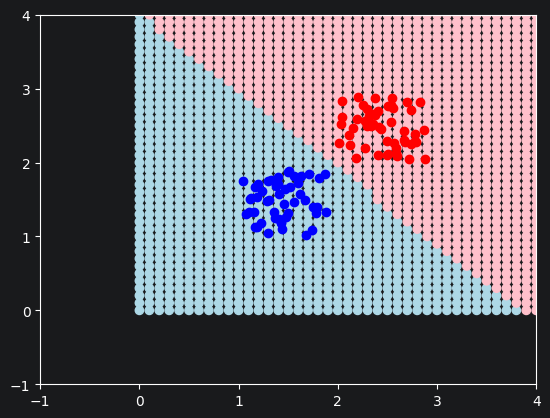

<Figure size 640x480 with 0 Axes>

In [10]:
plt.scatter( points_to_predict_[:,0], points_to_predict_[:,1], c=predicted_colors)

plt.scatter(X[0:50, 0], X[0:50, 1], color='blue')
plt.scatter(X[50:100,0], X[50:100,1], color='red')
#plt.scatter(clusters[:,0],clusters[:,1],marker = 'x', s = 100)

plt.xlim(-1, 4)
plt.ylim(-1, 4)

plt.show()
plt.clf()
rbf.close()

### XOR :
        Linear Model    : KO
        MLP (2, 2, 1)   : OK

In [11]:
X = np.array([[1, 0], [0, 1], [0, 0], [1, 1]], dtype=ctypes.c_float)
Y = np.array([1, 1, -1, -1], dtype=ctypes.c_float)

### CODE ADDED :

In [12]:
# RBF MODEL
'''
data_ptr = X.ctypes.data_as(ctypes.POINTER(ctypes.c_float))
label_ptr = Y.ctypes.data_as(ctypes.POINTER(ctypes.c_float))

env_x = np.array([0.0, 1.0], dtype=np.float32)
env_y = np.array([0.0, 1.0], dtype=np.float32)
env_x_ptr = env_x.ctypes.data_as(ctypes.POINTER(ctypes.c_float))
env_y_ptr = env_y.ctypes.data_as(ctypes.POINTER(ctypes.c_float))

num_k = 4

output = np.zeros(num_k * 2, dtype=np.float32)
output_ptr = output.ctypes.data_as(ctypes.POINTER(ctypes.c_float))



lib.lloyd(num_k, env_x_ptr, env_y_ptr, data_ptr, np.uint32(len(X)), 0.0001, 2000000000.0, output_ptr)
clusters = output.reshape((-1, 2))
#print(clusters)

clusters_ptr = clusters.ctypes.data_as(ctypes.POINTER(ctypes.c_float))

output = np.zeros(num_k, dtype=np.float32)

output_ptr = output.ctypes.data_as(
    ctypes.POINTER(ctypes.c_float)
)
gamma = 1.0


lib.RBF_train(
    gamma,
    data_ptr,
    np.uint32(len(X)),
    clusters_ptr,
    np.uint32(len(clusters)),
    label_ptr,
    output_ptr
)


points_to_predict = []
predicted_colors = []

for row in range(0, 100):
  for col in range(0, 100):

        data_point = np.array([col/100.0, row/100.0], dtype=np.float32)
        data_point_ptr = data_point.ctypes.data_as(ctypes.POINTER(ctypes.c_float))

        prediction = lib.RBF_predict(
            gamma,
            num_k,
            clusters_ptr,
            data_point_ptr,
            output_ptr
        )
        points_to_predict.append([prediction, col/100.0, row/100.0])
        predicted_colors.append('lightblue' if prediction>= 0 else 'pink')

#print(points_to_predict)
points_to_predict = np.array(points_to_predict)
'''
rbf = RBFModelRust(input_dim=2, nb_cluster=3, seed=5)

y_reshape = Y.reshape(-1, 1).astype(np.float32)

rbf.entrainement(X, y_reshape, 0.0001, 300, 20)



##### MODEL PREDICTION


In [13]:
points_to_predict_ = []
predicted_colors = []

for row in range(100):
    for col in range(100):
        point_to_predict_ = np.array(([row/100.0, col/100.0]), dtype = np.float32)
        points_to_predict_.append(point_to_predict_)

        pred = rbf.prediction(point_to_predict_.reshape(1, -1))

        predicted_colors.append('lightblue' if pred[0] >= 0 else 'pink')

points_to_predict_ = np.array(points_to_predict_)



### PLOT CREATION

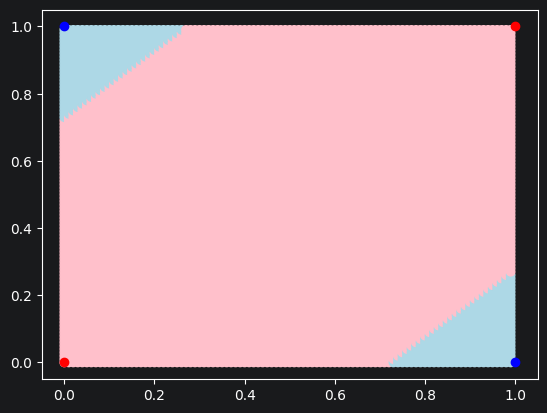

<Figure size 640x480 with 0 Axes>

In [14]:
plt.scatter(points_to_predict_[:,0], points_to_predict_[:,1], c=predicted_colors)
plt.scatter(X[0:2, 0], X[0:2, 1], color='blue')
plt.scatter(X[2:4,0], X[2:4,1], color='red')
#plt.scatter(clusters[:,0],clusters[:,1],marker = 'x', s = 100, c='black')
plt.show()
plt.clf()
rbf.close()

























































































### Cross :
        Linear Model    : KO
        MLP (2, 4, 1)   : OK

In [15]:
X = (np.random.random((500, 2)) * 2.0 - 1.0).astype(np.float32)
Y = (np.array([1 if abs(p[0]) <= 0.3 or abs(p[1]) <= 0.3 else -1 for p in X])).astype(np.float32)

### CODE ADDED :

In [16]:
rbf = RBFModelRust(input_dim=2, nb_cluster=15, seed=1)

y_reshape = Y.reshape(-1, 1).astype(np.float32)

rbf.entrainement(X, y_reshape, 0.0001, 300, 5)

In [17]:
points_to_predict_ = []
predicted_colors = []

for row in range(-100, 100):
    for col in range(-100, 100):
        point_to_predict_ = np.array(([row/100, col/100]), dtype= np.float32)
        points_to_predict_.append(point_to_predict_)

        pred = rbf.prediction(point_to_predict_.reshape(1, -1))

        predicted_colors.append('lightblue' if pred[0] >= 0 else 'pink')

points_to_predict_ = np.array(points_to_predict_)

### PLOT CREATION

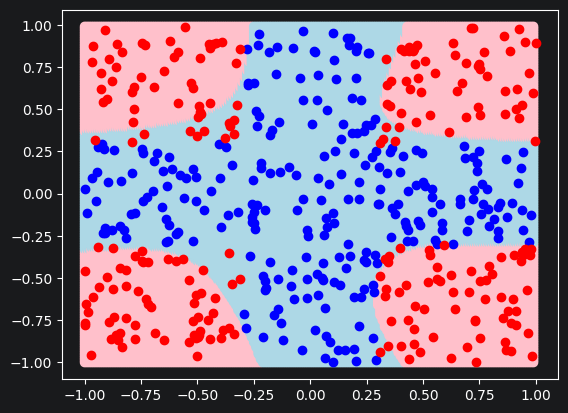

<Figure size 640x480 with 0 Axes>

In [18]:
plt.scatter( points_to_predict_[:,0], points_to_predict_[:,1], c=predicted_colors)

plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == 1, enumerate(X)))))[:,1], color='blue')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == -1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == -1, enumerate(X)))))[:,1], color='red')
#plt.scatter(clusters[:,0],clusters[:,1],marker = 'x', s = 100, c='black')
plt.show()
plt.clf()
rbf.close()

### Multi Linear 3 classes :
        Linear Model x3 : OK
        MLP (2, 3)      : OK

In [19]:
X = (np.random.random((500, 2)) * 2.0 - 1.0).astype(np.float32)
Y = np.array([[1, -1, -1] if -p[0] - p[1] - 0.5 > 0 and p[1] < 0 and p[0] - p[1] - 0.5 < 0 else
              [-1, 1, -1] if -p[0] - p[1] - 0.5 < 0 and p[1] > 0 and p[0] - p[1] - 0.5 < 0 else
              [-1, -1, 1] if -p[0] - p[1] - 0.5 < 0 and p[1] < 0 and p[0] - p[1] - 0.5 > 0 else
              [-1, -1, -1]for p in X]).astype(np.float32)

X = X[[not np.all(arr == [-1, -1, -1]) for arr in Y]]
Y = Y[[not np.all(arr == [-1, -1, -1]) for arr in Y]]

#print(Y)

### CODE ADDED :

In [20]:
'''Y1 = Y[:, 0].astype(np.float32)
Y2 = Y[:, 1].astype(np.float32)
Y3 = Y[:, 2].astype(np.float32)


data_ptr = (X).ctypes.data_as(ctypes.POINTER(ctypes.c_float))

labels_ptr1 = Y1.ctypes.data_as(ctypes.POINTER(ctypes.c_float))
labels_ptr2 = Y2.ctypes.data_as(ctypes.POINTER(ctypes.c_float))
labels_ptr3 = Y3.ctypes.data_as(ctypes.POINTER(ctypes.c_float))

env_x = np.array([-1.0, 1.0], dtype=np.float32)
env_y = np.array([-1.0, 1.0], dtype=np.float32)

env_x_ptr = env_x.ctypes.data_as(ctypes.POINTER(ctypes.c_float))
env_y_ptr = env_y.ctypes.data_as(ctypes.POINTER(ctypes.c_float))

num_k = 3

output = np.zeros(num_k * 2, dtype=np.float32)
output_ptr = output.ctypes.data_as(ctypes.POINTER(ctypes.c_float))



lib.lloyd(num_k, env_x_ptr, env_y_ptr, data_ptr, np.uint32(len(X)), 0.00001, 200000.0, output_ptr)
clusters = output.reshape((-1, 2))
#print(clusters)

clusters_ptr = clusters.ctypes.data_as(ctypes.POINTER(ctypes.c_float))

output1 = np.zeros(num_k, dtype=np.float32)
output2 = np.zeros(num_k, dtype=np.float32)
output3 = np.zeros(num_k, dtype=np.float32)


output_ptr1 = output1.ctypes.data_as(ctypes.POINTER(ctypes.c_float))
output_ptr2 = output2.ctypes.data_as(ctypes.POINTER(ctypes.c_float))
output_ptr3 = output3.ctypes.data_as(ctypes.POINTER(ctypes.c_float))
gamma = 1.0


lib.RBF_train(gamma, data_ptr, np.uint32(len(X)), clusters_ptr, np.uint32(len(clusters)), labels_ptr1, output_ptr1)
lib.RBF_train(gamma,data_ptr,np.uint32(len(X)),clusters_ptr, np.uint32(len(clusters)), labels_ptr2, output_ptr2)
lib.RBF_train(gamma,data_ptr,np.uint32(len(X)),clusters_ptr, np.uint32(len(clusters)), labels_ptr3, output_ptr3)

points_to_predict = []
predicted_colors = []

for row in range(-100, 100):
  for col in range(-100, 100):

        data_point = np.array([col/100.0, row/100.0], dtype=np.float32)
        data_point_ptr = data_point.ctypes.data_as( ctypes.POINTER(ctypes.c_float))

        prediction1 = lib.RBF_predict(gamma, num_k, clusters_ptr, data_point_ptr, output_ptr1)
        prediction2 = lib.RBF_predict(gamma, num_k, clusters_ptr, data_point_ptr, output_ptr2)
        prediction3 = lib.RBF_predict(gamma, num_k, clusters_ptr, data_point_ptr, output_ptr3)

        points_to_predict.append([col/100.0, row/100.0])
        predicted_colors.append('lightblue' if prediction1>= 0 else 'pink' if prediction2>= 0 else 'lightgreen' if prediction3>= 0 else 'white')

#print(points_to_predict)
points_to_predict = np.array(points_to_predict)
'''

rbf = OVRRBF(input_dim=2, output_dim=3 , seed=4, nb_cluster=3)
y_reshade = Y.reshape(-1, 1).astype(np.float32)
rbf.entrainement(X, Y, 0.0001, 3000, 5)


In [21]:
points_to_predict_ = []
predicted_colors = []

for row in range(-100, 100):
    for col in range(-100, 100):
        point_to_predict_ = np.array(([row/100.0, col/100.0]), dtype=np.float32)
        points_to_predict_.append(point_to_predict_)
        pred = rbf.prediction(point_to_predict_)
        colors = ['lightblue', 'pink', 'lightgreen']

        predicted_colors.append(colors[np.argmax(pred)])

points_to_predict_ = np.array(points_to_predict_)

### PLOT CREATION

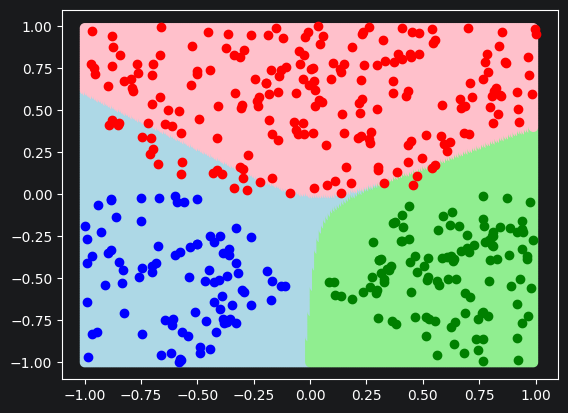

<Figure size 640x480 with 0 Axes>

In [22]:
plt.scatter(points_to_predict_[:,0], points_to_predict_[:,1], c=predicted_colors)

plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:,1], color='blue')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:,1], color='red')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:,1], color='green')

#plt.scatter(clusters[:,0],clusters[:,1],marker = 'x', s = 100, color = 'black')
plt.show()
plt.clf()
rbf.close()

### Multi Cross :
        Linear Model x3 : KO
        MLP (2, ?, ?, 3): OK

In [23]:
X = (np.random.random((1000, 2)) * 2.0 - 1.0).astype(np.float32)
Y = (np.array([[1, -1, -1] if abs(p[0] % 0.5) <= 0.25 and abs(p[1] % 0.5) > 0.25 else [-1, 1, -1] if abs(p[0] % 0.5) > 0.25 and abs(p[1] % 0.5) <= 0.25 else [-1, -1, 1] for p in X])).astype(np.float32)

### CODE ADDED :

In [24]:
'''Y1 = Y[:, 0].astype(np.float32)
Y2 = Y[:, 1].astype(np.float32)
Y3 = Y[:, 2].astype(np.float32)


data_ptr = (X).ctypes.data_as(ctypes.POINTER(ctypes.c_float))

labels_ptr1 = Y1.ctypes.data_as(ctypes.POINTER(ctypes.c_float))
labels_ptr2 = Y2.ctypes.data_as(ctypes.POINTER(ctypes.c_float))
labels_ptr3 = Y3.ctypes.data_as(ctypes.POINTER(ctypes.c_float))

env_x = np.array([-1.0, 1.0], dtype=np.float32)
env_y = np.array([-1.0, 1.0], dtype=np.float32)

env_x_ptr = env_x.ctypes.data_as(ctypes.POINTER(ctypes.c_float))
env_y_ptr = env_y.ctypes.data_as(ctypes.POINTER(ctypes.c_float))
num_k = 22

output = np.zeros(num_k * 2, dtype=np.float32)
output_ptr = output.ctypes.data_as(ctypes.POINTER(ctypes.c_float))



lib.lloyd(num_k, env_x_ptr, env_y_ptr, data_ptr, np.uint32(len(X)), 0.00001, 200000.0, output_ptr)
clusters = output.reshape((-1, 2))
print(clusters)

clusters_ptr = clusters.ctypes.data_as(ctypes.POINTER(ctypes.c_float))

output1 = np.zeros(num_k, dtype=np.float32)
output2 = np.zeros(num_k, dtype=np.float32)
output3 = np.zeros(num_k, dtype=np.float32)


output_ptr1 = output1.ctypes.data_as(ctypes.POINTER(ctypes.c_float))
output_ptr2 = output2.ctypes.data_as(ctypes.POINTER(ctypes.c_float))
output_ptr3 = output3.ctypes.data_as(ctypes.POINTER(ctypes.c_float))
gamma = 1.0


lib.RBF_train(gamma, data_ptr, np.uint32(len(X)), clusters_ptr, np.uint32(len(clusters)), labels_ptr1, output_ptr1)
lib.RBF_train(gamma,data_ptr,np.uint32(len(X)),clusters_ptr, np.uint32(len(clusters)), labels_ptr2, output_ptr2)
lib.RBF_train(gamma,data_ptr,np.uint32(len(X)),clusters_ptr, np.uint32(len(clusters)), labels_ptr3, output_ptr3)

points_to_predict = []
predicted_colors = []

for row in range(-100, 100):
  for col in range(-100, 100):

        data_point = np.array([col/100.0, row/100.0], dtype=np.float32)

        data_point_ptr = data_point.ctypes.data_as( ctypes.POINTER(ctypes.c_float))

        prediction1 = lib.RBF_predict(gamma, num_k, clusters_ptr, data_point_ptr, output_ptr1)
        prediction2 = lib.RBF_predict(gamma, num_k, clusters_ptr, data_point_ptr, output_ptr2)
        prediction3 = lib.RBF_predict(gamma, num_k, clusters_ptr, data_point_ptr, output_ptr3)
        points_to_predict.append([col/100.0, row/100.0])
        predicted_colors.append('lightblue' if prediction1>= 0 else 'pink' if prediction2>= 0 else 'lightgreen' if prediction3>= 0 else 'white')

#print(points_to_predict)
points_to_predict = np.array(points_to_predict)

'''

import random

seed_rand = int(random.random()*100)
print(seed_rand)

rbf = OVRRBF(input_dim=2, output_dim=3 , seed=seed_rand, nb_cluster=128)
y_reshade = Y.reshape(-1, 1).astype(np.float32)
rbf.entrainement(X, Y, 0.0001, 1000, 20)

#print("entrainement fini")
#print(rbf.prediction(X[:10]))

points_to_predict_ = []
predicted_colors = []

for row in range(-100, 100):
    for col in range(-100, 100):
        point_to_predict_ = np.array(([row/100.0, col/100.0]), dtype=np.float32)
        points_to_predict_.append(point_to_predict_)
        pred = rbf.prediction(point_to_predict_)
        colors = ['lightblue', 'pink', 'lightgreen']

        predicted_colors.append(colors[np.argmax(pred[0])])

points_to_predict_ = np.array(points_to_predict_)




58


### PLOT CREATION

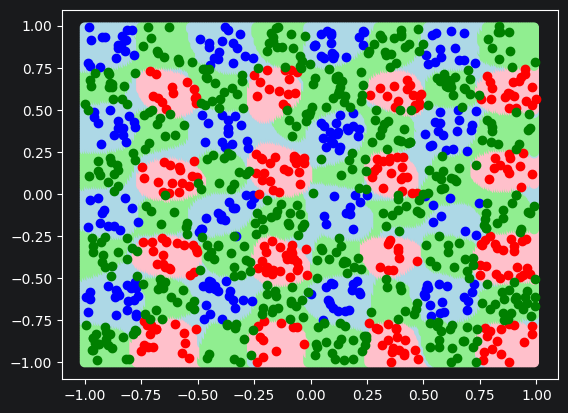

<Figure size 640x480 with 0 Axes>

In [25]:
plt.scatter(
    points_to_predict_[:,0],
    points_to_predict_[:,1],
    c=predicted_colors
)
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:,1], color='blue')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:,1], color='red')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:,1], color='green')

#plt.scatter(clusters[:,0],clusters[:,1],marker = 'x', s = 100, color = 'yellow')
plt.show()
plt.clf()

rbf.close()

## Régression

### Linear Simple 2D :
        Linear Model : OK
        MLP (1, 1)   : OK

In [26]:
X = np.array([
      [1],
      [2]
])
Y = np.array([
      2,
      3
])

### CODE ADDED :

### PLOT CREATION

In [ ]:
plt.scatter(X,Y)
plt.show()
plt.clf()

### Non Linear Simple 2D :
        Linear Model    : OK
        MLP (1, ?, 1)   : OK

In [ ]:
X = np.array([
      [1],
      [2],
      [3]
])
Y = np.array([
      2,
      3,
      2.5
])

### CODE ADDED :

### PLOT CREATION

In [ ]:
plt.scatter(X,Y)
plt.show()
plt.clf()

### Linear Simple 3D :
        Linear Model    : OK
        MLP (2, 1)      : OK

In [ ]:
X = np.array([
      [1, 1],
      [2, 2],
      [3, 1]
])
Y = np.array([
      2,
      3,
      2.5
])

### CODE ADDED :

### PLOT CREATION

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = Axes3D(fig)
ax.scatter(X[:,0],X[:,1],Y)
plt.show()
plt.clf()

### Linear Tricky 3D :
        Linear Model    : OK
        MLP (2, 1)      : OK

In [ ]:
X = np.array([
      [1, 1],
      [2, 2],
      [3, 3]
])
Y = np.array([
      1,
      2,
      3
])

### CODE ADDED :

### PLOT CREATION

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = Axes3D(fig)
ax.scatter(X[:,0],X[:,1],Y)
plt.show()
plt.clf()

### Non Linear Simple 3D :
        Linear Model       : KO
        MLP (2, 2, 1)      : OK

In [ ]:
X = np.array([
      [1, 0],
      [0, 1],
      [1, 1],
      [0, 0],
])
Y = np.array([
      2,
      1,
      -2,
      -1
])

### CODE ADDED :

### PLOT CREATION

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = Axes3D(fig)
ax.scatter(X[:,0],X[:,1],Y)
plt.show()
plt.clf()